# Sesión de clase 08 · Ejercicio 1: tópicos con LDA en `comentarios.csv`

El **análisis de tópicos** descubre, sin etiquetas previas, los temas de los
que habla una colección de documentos. Produce dos salidas:

1. **Tópicos descritos por palabras** (φ): cada tópico es una distribución de
   probabilidad sobre el vocabulario.
2. **Mezcla de tópicos por documento** (θ): qué proporción de cada tópico hay
   en cada texto.

**LDA** (*Latent Dirichlet Allocation*, Blei, Ng y Jordan, 2003) estima ambas
cosas a partir de una **bolsa de palabras**: solo ve cuántas veces aparece
cada palabra en cada documento y qué palabras aparecen juntas.

Trabajamos con los **135 comentarios** de `data/comentarios.csv`.

**Etapas:** 1. Cargar · 2. Preprocesar · 3. Frecuencias y co-ocurrencia ·
4. Entrenar LDA · 5. Interpretar · 6. Evaluar (coherencia NPMI y
diversidad) · Discusión.

In [4]:
import itertools
import re
import unicodedata

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

pd.set_option("display.max_colwidth", 120)

AZUL, ROJO, GRIS, TINTA = "#2a78d6", "#e34948", "#8a8985", "#52514e"
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": GRIS, "axes.labelcolor": TINTA,
    "xtick.color": TINTA, "ytick.color": TINTA,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "figure.dpi": 110,
})

## 1. Cargar

Columnas: `id`, `cliente_id`, `cliente_ciudad`, `cliente_pais`,
`calificacion` (1–5★), `fecha` y `texto`.

In [5]:
df = pd.read_csv("../data/comentarios.csv")
print(df.shape)
df.sample(5, random_state=7)

(135, 7)


,id,cliente_id,cliente_ciudad,cliente_pais,calificacion,fecha,texto
134,419,5,Arequipa,Peru,1,2024-01-15,El sistema de puntos se reinicio sin explicacion despues de una actualizacion de la plataforma. Perdi el saldo acumu...
107,332,53,Santiago,Chile,2,2024-07-20,El chat de soporte demoro mas de media hora en responder un dia de alta demanda.
98,397,46,Valparaiso,Chile,1,2024-09-22,Recibi un correo de confirmacion pero el pedido nunca aparecio en mi historial de compras. Tuve que llamar por telef...
81,432,83,Cordoba,Argentina,2,2025-01-13,"El diseno del sitio en el celular se ve desordenado en pantallas pequenas, algunos botones quedan superpuestos."
123,324,21,Puno,Peru,5,2024-03-30,"Excelente variedad de marcas, encontre opciones que no tenia en otras tiendas."


In [6]:
largo = df["texto"].str.split().str.len()
print(f"Palabras por comentario: mínimo {largo.min()}, mediana {largo.median():.0f}, "
      f"máximo {largo.max()}")
df["calificacion"].value_counts().sort_index().rename("comentarios").to_frame().T

Palabras por comentario: mínimo 8, mediana 15, máximo 32


calificacion,1,2,3,4,5
comentarios,17,25,31,30,32


Son **textos cortos** (unas 15 palabras): cada comentario ofrece muy pocas
co-ocurrencias. Esto será importante al evaluar LDA.

## 2. Preprocesar

Cuatro pasos habituales:

1. **Normalizar:** minúsculas y sin tildes (los textos del archivo casi no las
   usan, así «demoró» y «demoro» quedan iguales).
2. **Quitar *stopwords*:** palabras funcionales («el», «de», «que») más
   palabras del **dominio** que aparecen en todos los temas («tienda»,
   «producto», «compra»).
3. **Lematizar** («demoró» → demorar). Requiere spaCy u otro lematizador; aquí
   lo omitimos y lo dejamos como mejora.
4. **N-gramas:** unir términos que van juntos («alta demanda»).

`CountVectorizer` de scikit-learn solo trae *stopwords* en **inglés**
(`stop_words="english"`), por eso definimos `STOPWORDS_ES`.

In [7]:
def normalizar(texto):
    """Minúsculas y sin tildes."""
    t = unicodedata.normalize("NFKD", texto.lower())
    return "".join(ch for ch in t if not unicodedata.combining(ch))


STOPWORDS_ES = sorted(set("""
a al algo algun alguna algunas alguno algunos ante antes aqui asi aun aunque
bajo bien cada casi como con contra cual cuando de del desde donde dos durante
e el ella ellas ellos en entre era eran es esa esas ese eso esos esta estaba
estaban estan estar este esto estos fue fueron ha habia han hasta hay he la las
le les lo los mas me mi mis mucho muy nada ni no nos o otra otras otro otros
para pero poco por porque que se ser si sin sobre solo su sus tambien tan tanto
te tiene todo todos tu tuve un una uno unos y ya yo vez veces mismo misma
son podria poder bastante
""".split()))

print(len(STOPWORDS_ES), "stopwords")

119 stopwords


Veamos cómo queda un comentario real: en **mayúsculas** las palabras que se
conservan, en minúsculas las *stopwords* que se descartan.

In [9]:
ejemplo = df.loc[df["texto"].str.contains("media hora"), "texto"].iloc[0]
tokens = re.findall(r"\w+", normalizar(ejemplo))
print(ejemplo)
print(" ".join(t if t in STOPWORDS_ES else t.upper() for t in tokens))

El chat de soporte demoro mas de media hora en responder un dia de alta demanda.
el CHAT de SOPORTE DEMORO mas de MEDIA HORA en RESPONDER un DIA de ALTA DEMANDA


## 3. Frecuencias y co-ocurrencia

### 3.1 Términos más frecuentes

`CountVectorizer(min_df=2)` arma el vocabulario con los términos que aparecen
en al menos 2 comentarios. Contamos en **cuántos comentarios** aparece cada
término.

135 comentarios × 220 términos distintos


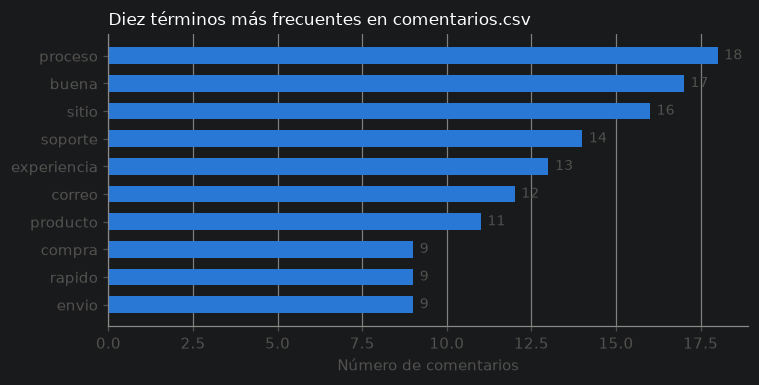

In [10]:
cv = CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_ES, min_df=2)
X = cv.fit_transform(df["texto"])
vocab = cv.get_feature_names_out()
print(f"{X.shape[0]} comentarios × {X.shape[1]} términos distintos")

docs_por_termino = pd.Series(np.asarray((X > 0).sum(axis=0)).ravel(), index=vocab)
top10 = docs_por_termino.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.barh(top10.index[::-1], top10.values[::-1], color=AZUL, height=0.6)
for i, v in enumerate(top10.values[::-1]):
    ax.text(v + 0.2, i, str(v), va="center", color=TINTA, fontsize=9)
ax.set_xlabel("Número de comentarios")
ax.set_title("Diez términos más frecuentes en comentarios.csv", loc="left", fontsize=11)
ax.grid(axis="y", visible=False)
plt.tight_layout()
plt.show()

**Frecuente no es lo mismo que tema.** Términos como «proceso», «buena» o
«experiencia» aparecen en comentarios de pagos, de soporte y de envíos: no
identifican ningún tema. Comprobémoslo leyendo algunos:

In [11]:
df.loc[df["texto"].map(normalizar).str.contains(r"\bproceso\b"), ["calificacion", "texto"]].head(6)

,calificacion,texto
0,5,El proceso de facturacion para empresa fue mas simple de lo que esperaba.
4,3,El proceso de devolucion fue sencillo de iniciar aunque tomo unos dias en confirmarse.
15,2,El proceso de cambio de producto por otro modelo fue mas lento de lo esperado.
29,3,"El proceso de pago es estandar, similar a lo que ya conozco de otras tiendas en linea."
39,3,El proceso de canje de puntos podria explicarse mejor en la pagina de ayuda.
45,3,"El proceso de registro es sencillo, aunque pide confirmar el correo un paso adicional que otros sitios no piden."


### 3.2 Matriz documento-término y co-ocurrencia

Cada fila es un documento, cada columna una palabra; la celda cuenta cuántas
veces aparece. Con cinco documentos pequeños se ve la idea clave de LDA: **las
palabras que aparecen juntas en los mismos documentos forman un tópico.**

In [12]:
mini = ["chat de soporte con mucha espera",
        "el soporte tardo, mucha espera",
        "cobro duplicado en la tarjeta",
        "reembolso del cobro a la tarjeta",
        "el chat no resolvio el reembolso"]
terminos = ["chat", "soporte", "espera", "cobro", "tarjeta", "reembolso"]

cv_mini = CountVectorizer(vocabulary=terminos)
M = cv_mini.fit_transform(mini)
pd.DataFrame(M.toarray(), columns=terminos, index=[f"D{i+1} «{d}»" for i, d in enumerate(mini)])

,chat,soporte,espera,cobro,tarjeta,reembolso
D1 «chat de soporte con mucha espera»,1,1,1,0,0,0
"D2 «el soporte tardo, mucha espera»",0,1,1,0,0,0
D3 «cobro duplicado en la tarjeta»,0,0,0,1,1,0
D4 «reembolso del cobro a la tarjeta»,0,0,0,1,1,1
D5 «el chat no resolvio el reembolso»,1,0,0,0,0,1


`Mᵀ · M` cuenta en cuántos documentos aparece **cada par** de palabras
(co-ocurrencia). Se forman dos bloques: {chat, soporte, espera} y {cobro,
tarjeta, reembolso}. D5 mezcla palabras de ambos: **un documento puede
pertenecer a varios tópicos a la vez.**

In [13]:
pd.DataFrame((M.T @ M).toarray(), index=terminos, columns=terminos)

,chat,soporte,espera,cobro,tarjeta,reembolso
chat,2,1,1,0,0,1
soporte,1,2,2,0,0,0
espera,1,2,2,0,0,0
cobro,0,0,0,2,2,1
tarjeta,0,0,0,2,2,1
reembolso,1,0,0,1,1,2


## 4. Entrenar LDA

LDA supone que cada documento se escribió así:

1. Elegir la mezcla de tópicos del documento: θ ~ Dirichlet(α).
2. Para cada palabra, elegir un tópico: z ~ Multinomial(θ).
3. Elegir la palabra dentro de ese tópico: w ~ Multinomial(φ_z).

El modelo observa **solo las palabras** y estima θ y φ «al revés» (scikit-learn
usa inferencia variacional).

| Hiperparámetro | scikit-learn | Efecto |
| --- | --- | --- |
| K | `n_components` | Pocos tópicos mezclan temas; demasiados los fragmentan |
| α | `doc_topic_prior` | Bajo: cada documento usa pocos tópicos |
| β | `topic_word_prior` | Bajo: tópicos definidos por pocas palabras dominantes |

En textos cortos conviene un **α bajo**: cada comentario trata pocos temas.

In [14]:
K = 5
lda = LatentDirichletAllocation(n_components=K, doc_topic_prior=0.1,
                                topic_word_prior=0.01, random_state=42)
theta = lda.fit_transform(X)                      # θ: documentos × tópicos
phi = lda.components_ / lda.components_.sum(axis=1, keepdims=True)  # φ: tópicos × palabras

print("θ:", theta.shape, "   φ:", phi.shape)
print("Cada fila de θ suma 1:", np.allclose(theta.sum(axis=1), 1))

θ: (135, 5)    φ: (5, 220)
Cada fila de θ suma 1: True


## 5. Interpretar

### 5.1 Palabras con mayor peso en cada tópico (top-8 de φ)

In [15]:
def top_palabras(componentes, n=8):
    return [[vocab[i] for i in fila.argsort()[::-1][:n]] for fila in componentes]


df["topico_lda"] = theta.argmax(axis=1)
resumen = pd.DataFrame({
    "palabras con mayor peso": [", ".join(p) for p in top_palabras(lda.components_)],
    "comentarios": df["topico_lda"].value_counts().sort_index(),
    "calif. promedio": df.groupby("topico_lda")["calificacion"].mean().round(1),
}).rename_axis("tópico")
resumen

,palabras con mayor peso,comentarios,calif. promedio
tópico,,,
0,"experiencia, sitio, soporte, general, comprar, tiempo, chat, buena",31,3.4
1,"buena, garantia, resolver, opciones, atencion, accesorios, experiencia, conforme",23,3.8
2,"proceso, pedido, pago, rapido, sitio, dias, busqueda, tres",37,3.2
3,"puntos, soporte, proceso, correo, tardo, servicio, problema, sistema",22,3.0
4,"proceso, producto, envio, tiendas, varias, precio, productos, comparado",22,2.9


**¿Qué nombre le pondrían a cada tópico?** Fíjense en cuántas palabras
genéricas («proceso», «buena», «experiencia», «compra») se repiten entre
tópicos.

### 5.2 Pesos de φ en un gráfico

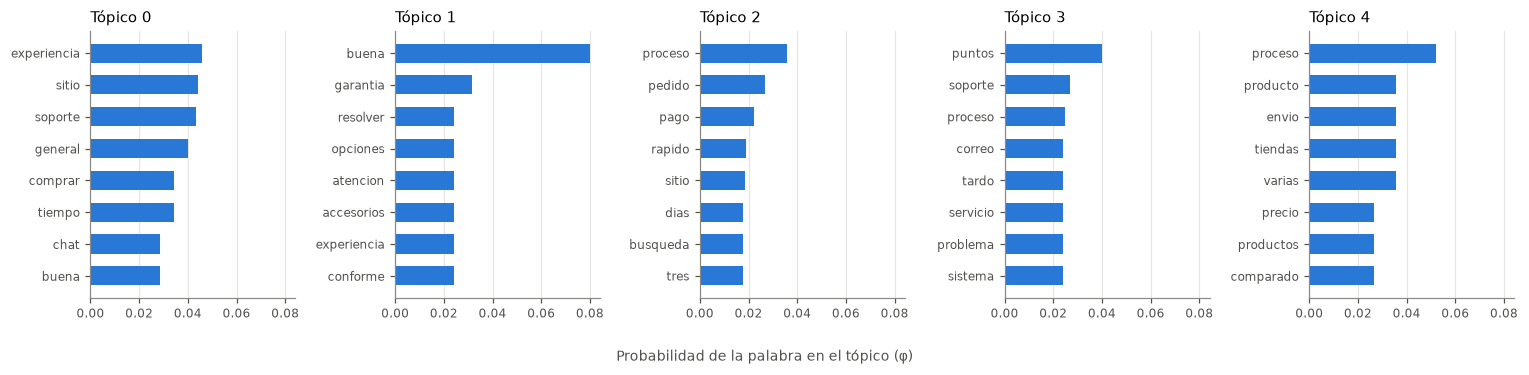

In [12]:
fig, axes = plt.subplots(1, K, figsize=(14, 3.4), sharex=True)
for k, ax in enumerate(axes):
    orden = phi[k].argsort()[::-1][:8]
    ax.barh([vocab[i] for i in orden][::-1], phi[k][orden][::-1], color=AZUL, height=0.6)
    ax.set_title(f"Tópico {k}", loc="left", fontsize=10)
    ax.grid(axis="y", visible=False)
    ax.tick_params(labelsize=8)
fig.supxlabel("Probabilidad de la palabra en el tópico (φ)", fontsize=9, color=TINTA)
plt.tight_layout()
plt.show()

### 5.3 Un documento es una mezcla de tópicos (θ)

Tres comentarios con su mezcla estimada. El tópico «dominante» (`argmax`) es
una simplificación: LDA reparte cada documento entre varios tópicos.

In [16]:
muestra = df.sample(3, random_state=3).index
pd.concat([df.loc[muestra, ["texto"]],
           pd.DataFrame(theta[muestra], index=muestra,
                        columns=[f"T{k}" for k in range(K)]).round(2)], axis=1)

,texto,T0,T1,T2,T3,T4
15,El proceso de cambio de producto por otro modelo fue mas lento de lo esperado.,0.02,0.02,0.02,0.02,0.94
73,El servicio de asistencia por correo respondio con una plantilla generica que no resolvia mi problema especifico.,0.02,0.02,0.02,0.91,0.02
57,Un vendedor de soporte me dio informacion incorrecta sobre un plazo de entrega y tuve que reprogramar mis planes.,0.03,0.03,0.03,0.89,0.03


### 5.4 Efecto de α en la mezcla

Con α = 0.1 la mayor parte de cada documento cae en un solo tópico; con α = 1
las mezclas se vuelven más uniformes. Lo medimos con el **peso del tópico
dominante** promedio.

In [17]:
for alfa in [0.1, 1.0]:
    t = LatentDirichletAllocation(n_components=K, doc_topic_prior=alfa,
                                  topic_word_prior=0.01, random_state=42).fit_transform(X)
    print(f"α = {alfa:<4}  peso promedio del tópico dominante = {t.max(axis=1).mean():.2f}")

α = 0.1   peso promedio del tópico dominante = 0.89
α = 1.0   peso promedio del tópico dominante = 0.44


## 6. Evaluar

### 6.1 Coherencia NPMI

¿Las palabras principales de un tópico **aparecen juntas** en los documentos?

NPMI(wᵢ, wⱼ) = log[ P(wᵢ, wⱼ) / (P(wᵢ) P(wⱼ)) ] / −log P(wᵢ, wⱼ)

- **+1:** las dos palabras siempre aparecen juntas.
- **0:** aparecen juntas lo que se esperaría por azar.
- **−1:** nunca aparecen juntas.

Se promedia sobre todos los pares de las top-n palabras de cada tópico. Las
probabilidades se estiman como proporción de documentos.

In [18]:
B = (X > 0).toarray()          # presencia (1) o ausencia (0) de cada término


def npmi_par(i, j, B=B):
    p_i, p_j = B[:, i].mean(), B[:, j].mean()
    p_ij = (B[:, i] & B[:, j]).mean()
    if p_ij == 0:
        return -1.0
    if p_ij == 1:
        return 1.0
    return np.log(p_ij / (p_i * p_j)) / -np.log(p_ij)


def coherencia(componentes, n=6):
    """NPMI promedio de cada tópico sobre los pares de sus top-n palabras."""
    return [np.mean([npmi_par(i, j)
                     for i, j in itertools.combinations(fila.argsort()[::-1][:n], 2)])
            for fila in componentes]


def diversidad(componentes, n=6):
    """Proporción de palabras únicas entre las top-n de todos los tópicos."""
    tops = [p for fila in top_palabras(componentes, n) for p in fila]
    return len(set(tops)) / len(tops)


resumen["NPMI"] = np.round(coherencia(lda.components_), 2)
print(f"Coherencia NPMI promedio: {np.mean(resumen['NPMI']):.2f}")
print(f"Diversidad (top-6):       {diversidad(lda.components_):.2f}")
resumen

Coherencia NPMI promedio: -0.29
Diversidad (top-6):       0.87


,palabras con mayor peso,comentarios,calif. promedio,NPMI
tópico,,,,
0,"experiencia, sitio, soporte, general, comprar, tiempo, chat, buena",31,3.4,-0.42
1,"buena, garantia, resolver, opciones, atencion, accesorios, experiencia, conforme",23,3.8,-0.28
2,"proceso, pedido, pago, rapido, sitio, dias, busqueda, tres",37,3.2,-0.16
3,"puntos, soporte, proceso, correo, tardo, servicio, problema, sistema",22,3.0,-0.38
4,"proceso, producto, envio, tiendas, varias, precio, productos, comparado",22,2.9,-0.19


Una NPMI promedio **negativa** indica que las palabras de un mismo tópico rara
vez aparecen juntas en un comentario. Con 135 textos cortos, LDA no logra
separar los temas con claridad.

### 6.2 Coherencia según el número de tópicos K

Probamos K de 2 a 10. En corpus grandes la curva suele subir, estabilizarse y
luego decaer; se elige K donde se estabiliza **y** los tópicos tienen sentido
para el negocio.

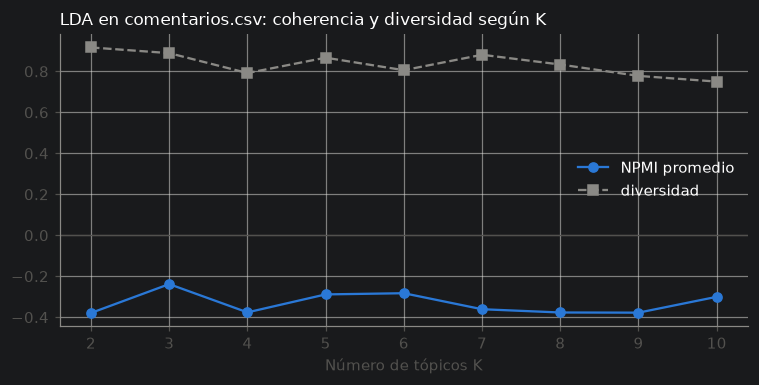

K,2,3,4,5,6,7,8,9,10
NPMI,-0.38,-0.24,-0.38,-0.29,-0.28,-0.36,-0.38,-0.38,-0.30
diversidad,0.92,0.89,0.79,0.87,0.81,0.88,0.83,0.78,0.75


In [19]:
filas = []
for k in range(2, 11):
    m = LatentDirichletAllocation(n_components=k, doc_topic_prior=0.1,
                                  topic_word_prior=0.01, random_state=42).fit(X)
    filas.append({"K": k, "NPMI": np.mean(coherencia(m.components_)),
                  "diversidad": diversidad(m.components_)})
curva = pd.DataFrame(filas).set_index("K")

fig, ax = plt.subplots(figsize=(7, 3.6))
ax.plot(curva.index, curva["NPMI"], "o-", color=AZUL, label="NPMI promedio")
ax.plot(curva.index, curva["diversidad"], "s--", color=GRIS, label="diversidad")
ax.axhline(0, color=TINTA, linewidth=0.8)
ax.set_xlabel("Número de tópicos K")
ax.set_title("LDA en comentarios.csv: coherencia y diversidad según K", loc="left", fontsize=11)
ax.legend(frameon=False)
plt.tight_layout()
plt.show()
curva.round(2).T

## Discusión

### ¿Qué ocurre con K = 3 y con K = 8?

In [20]:
for k in [3, 8]:
    m = LatentDirichletAllocation(n_components=k, doc_topic_prior=0.1,
                                  topic_word_prior=0.01, random_state=42).fit(X)
    print(f"--- K = {k}")
    for i, palabras in enumerate(top_palabras(m.components_, 6)):
        print(f"  {i}: {', '.join(palabras)}")

--- K = 3
  0: comprar, soporte, tiempo, chat, mejor, correo
  1: buena, experiencia, soporte, sitio, general, busqueda
  2: proceso, envio, sitio, pedido, pago, tiendas
--- K = 8
  0: correo, general, mejor, minutos, compras, registro
  1: buena, garantia, atencion, accesorios, producto, resolver
  2: sitio, pago, rapido, proceso, tiendas, opciones
  3: soporte, producto, puntos, error, descuento, facil
  4: proceso, varias, tres, lento, precios, primera
  5: pedido, proceso, correo, dias, comprar, electronica
  6: tiempo, soporte, sitio, marca, tener, espera
  7: experiencia, buena, compra, envio, general, tienda


### ¿Qué palabras agregarían a `STOPWORDS_ES`?

Agreguemos palabras de **dominio** y de **valoración genérica** que no
identifican temas, y usemos bigramas (`ngram_range=(1, 2)`). Comparen las
palabras y la coherencia con el modelo original.

In [21]:
STOPWORDS_DOMINIO = STOPWORDS_ES + [
    "tienda", "tiendas", "producto", "productos", "compra", "comprar", "proceso",
    "experiencia", "buena", "general", "tiempo",
]

cv2 = CountVectorizer(preprocessor=normalizar, stop_words=STOPWORDS_DOMINIO,
                      min_df=2, ngram_range=(1, 2))
X2 = cv2.fit_transform(df["texto"])
vocab2 = cv2.get_feature_names_out()
B2 = (X2 > 0).toarray()
lda2 = LatentDirichletAllocation(n_components=K, doc_topic_prior=0.1,
                                 topic_word_prior=0.01, random_state=42).fit(X2)

npmi2 = [np.mean([npmi_par(i, j, B2)
                  for i, j in itertools.combinations(f.argsort()[::-1][:6], 2)])
         for f in lda2.components_]
pd.DataFrame({
    "palabras con mayor peso": [", ".join(vocab2[i] for i in f.argsort()[::-1][:8])
                                for f in lda2.components_],
    "NPMI": np.round(npmi2, 2),
}).rename_axis("tópico")

,palabras con mayor peso,NPMI
tópico,,
0,"sitio, pago, compras, resolver, opciones, puntos, pedido, diseno",-0.65
1,"envio, despues, atencion, pago, modelo, correo, rapido, registro",-0.80
2,"real, siempre, tecnologia, sitio, soporte, dias, checkout, dia",-0.40
3,"soporte, correo, garantia, busqueda, minutos, mejor, rapido, deberian",-0.49
4,"tres, catalogo, envio, funciona, distintos, decidir, recibi, soporte",-0.50


Preguntas para el grupo:

- ¿Mejoró la interpretabilidad al quitar palabras de dominio? ¿Y la NPMI?
  ¿Siempre van de la mano?
- Cambien `random_state` (p. ej., 0, 1, 7): ¿se mantienen los tópicos? ¿Qué
  dice eso sobre la estabilidad de LDA con 135 comentarios?
- LDA trata «demoro», «tardo» y «lento» como tres palabras distintas. ¿Qué
  representación vista en clases anteriores los pondría juntos? Esa es la
  idea de BERTopic (Ejercicio 2).

In [19]:
# Espacio para experimentar: cambien K, α, β, la semilla o las stopwords